# Addestramento Logistic Regression e analisi delle features
In questo notebook, tramite il dataset precedentemente creato, verrà addestrato un classificatore semplice (Logistic Regression) per poi effettuare un'analisi sulle feature che influiscono maggiormente sulla classificazione delle frasi.

In [2]:
import pandas as pd

df = pd.read_csv('../data/processed/ai_human_sentences.csv')

## Addestramento del modello
Vengono definiti set di addestramento (80%) e test (20%) mantenendo in entrambi una distribuzione proporzionata delle due classi. Successivamente viene inizializzato il TfidfVectorizer, utilizzato per trasformare le frasi in vettori numerici sulla base di unigrammi e bigrammi. Le feature troppo rare, presenti in meno di cinque frasi, vengono escluse.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    df["masked_sentence"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Valutazione del modello

Una volta addestrato, il modello viene applicato al set di test per confrontare le classi predette con quelle reali. La valutazione viene effettuata tramite precision, recall, F1-score e accuracy.

Il modello raggiunge un'accuracy complessiva di circa 0,83.
I risultati mostrano che anche dopo aver mascherato i riferimenti espliciti alle due categorie, il contesto linguistico contiene informazioni sufficienti per distinguerle con una buona accuratezza.

In [4]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          AI       0.81      0.92      0.86      2555
       human       0.86      0.70      0.77      1789

    accuracy                           0.83      4344
   macro avg       0.84      0.81      0.82      4344
weighted avg       0.83      0.83      0.83      4344



In [10]:
model.classes_

array(['AI', 'human'], dtype=object)

## Interpretazione tramite SHAP

Tramite la libreria SHAP vengono analizzate le feature che contribuiscono alla classificazione, nei grafici seguenti vengono mostrati i primi venti risultati per Human e successivamente i primi venti risultati per AI. L'ultimo grafico invece mostra il peso delle feature e verso quale label "spingono"

In [7]:
import shap

feature_names = vectorizer.get_feature_names_out()

explainer = shap.LinearExplainer(
    model,
    X_train_tfidf,
    feature_names=feature_names
)

shap_values = explainer(X_test_tfidf)

/Users/francesco/Desktop/progetto_tirocinio/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


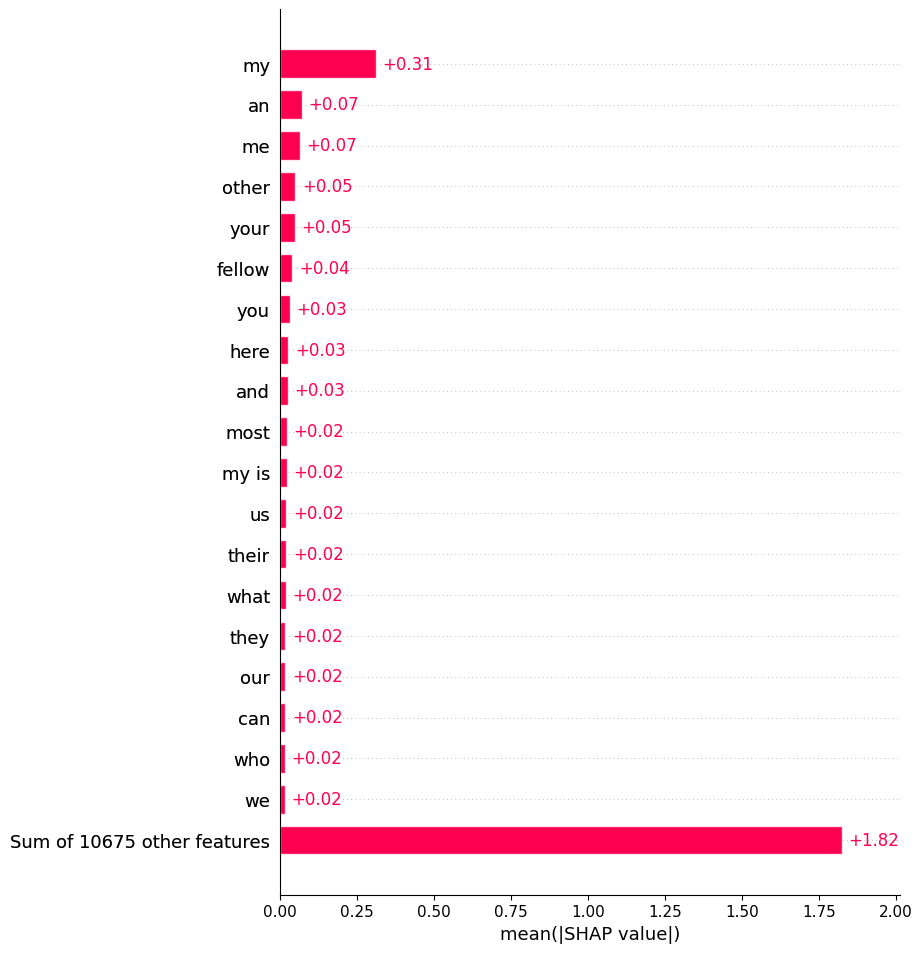

In [8]:
import numpy as np

human_values = shap.Explanation(
    values=np.clip(shap_values.values, 0, None),
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

shap.plots.bar(human_values, max_display=20)

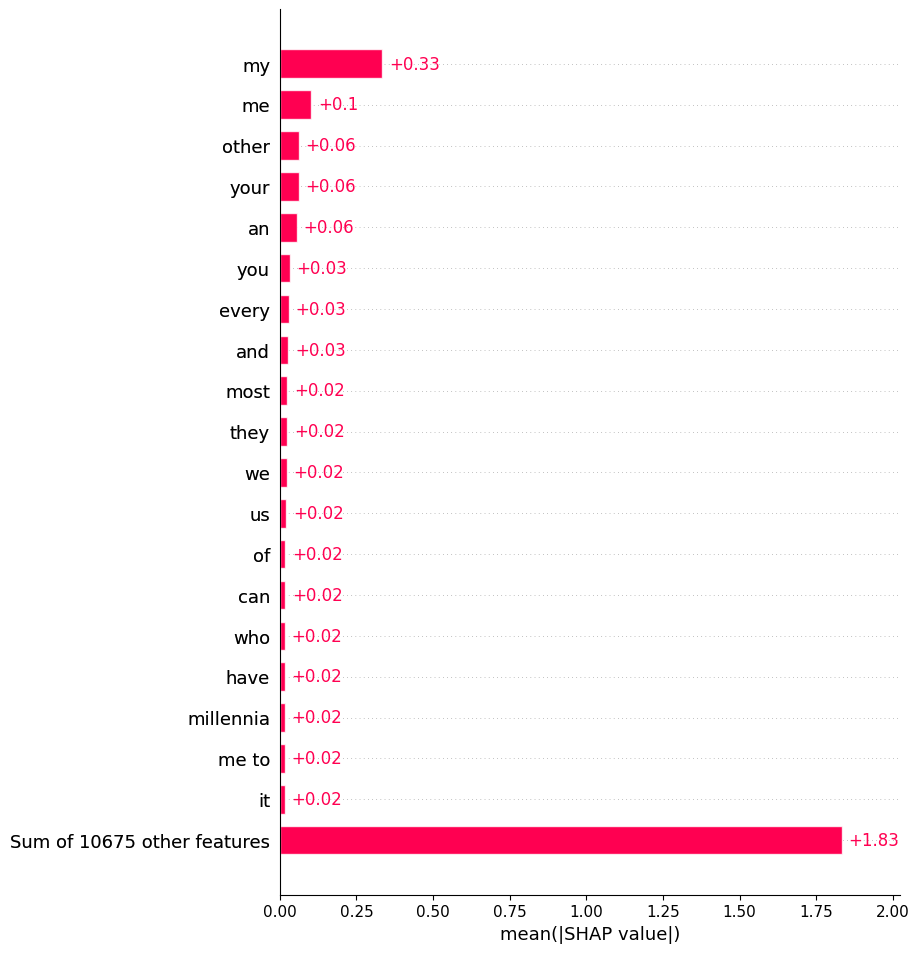

In [9]:
ai_values = shap.Explanation(
    values=np.clip(-shap_values.values, 0, None),
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

shap.plots.bar(ai_values, max_display=20)

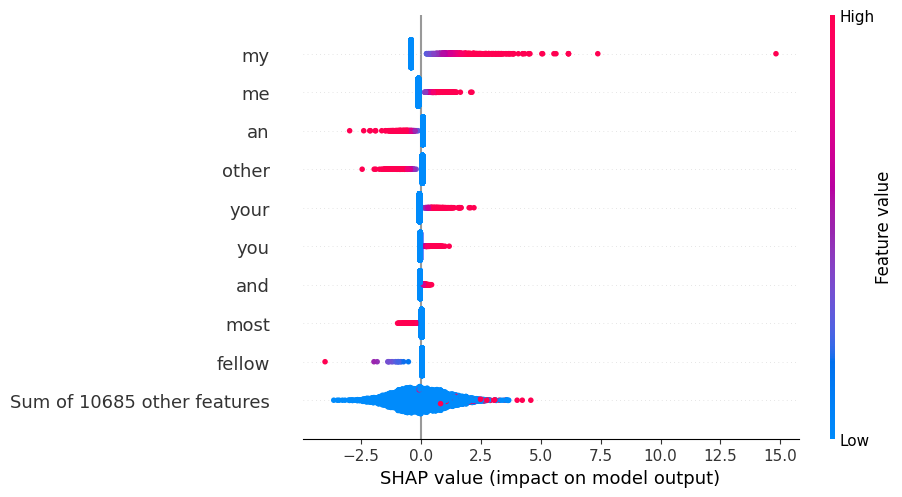

In [17]:
shap.plots.beeswarm(shap_values)